# 08 · Failure Attribution

**Purpose.** For every non-coordinate-correct prediction, separate **tool failure** from
**reference/truth gap** and **annotation disagreement**. This is the biological-insight section, and
the honest counterweight to a high headline accuracy. Feeds **Figure 6**.

**Attribution is done by the shipped `adjudicate_failures()`**, not by a rule written here. That
function is deliberately generic — it decides from `pred/ref/truth` length deltas and coverage
alone, with **no virus name and no gene name anywhere** — so the attribution cannot be accused of
being tuned to make the tool look good.

## Inputs

The per-prediction table from 04a (`tblastn_vs_truth.tsv`) + truth annotation profile.

In [1]:
from pathlib import Path
import sys, time

import pandas as pd
import matplotlib.pyplot as plt

# --- anchor ROOT to the repo (folder that contains app/src) ---
ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "app" / "src").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA   = ROOT / "app" / "data"
CONFIG = ROOT / "app" / "config"

# References (verify these are the intended ref records for the paper):
FMD_REF    = DATA / "FMD"  / "FMD_ref_test.gb"        # alt: FMD_FJ175661_Anno.gb
FMD_QUERY  = DATA / "FMD"  / "FMD_100seq_anno.gb"
PRRS_REF   = DATA / "PRRS" / "PRRS_ref_test.gb"       # alt: PRRS_MT746146_Anno.gb
PRRS_QUERY = DATA / "PRRS" / "PRRS_100seq_anno.gb"
PED_REFS   = {"ref_1": DATA / "PED" / "PED_ref_1.gb",
              "ref_2": DATA / "PED" / "PED_ref_2.gb"}
PED_QUERY  = DATA / "PED" / "PED_100seqs.gb"

# Run toggle: keep False for a fast smoke test, True for the full 100-record run.
RUN_FULL = False
SAMPLE_N = 10


In [2]:
# outputs land inside this unit folder so figures/tables sit next to the notebook
UNIT_DIR = ROOT / "app" / "validation" / "08_failure_attribution"
OUT = UNIT_DIR / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
print("outputs ->", OUT)

outputs -> /root/work/app/validation/08_failure_attribution/outputs


## Load — the per-prediction table from 02_lifting_accuracy

Regenerated here if absent, using the same `run_lifting_accuracy` harness, so this unit never scores
a stale table.

In [3]:
from app.validation._shared.validation_utils import (
    run_lifting_accuracy, adjudicate_failures, load_reference_bundle,
    load_genbank_records, build_truth_presence, attach_ref_lengths,
)

ACC = ROOT / "app" / "validation" / "02_lifting_accuracy" / "outputs"
PAIRS = {"prrs": (PRRS_REF, PRRS_QUERY), "fmd": (FMD_REF, FMD_QUERY),
         "ped":  (DATA / "PED" / "PED_ref_1.gb", DATA / "PED" / "PED_100seqs.gb")}

# adjudicate_failures needs ref_len / pred_minus_ref_len / truth_minus_ref_len, which are added by
# attach_ref_lengths -- run_lifting_accuracy already does that, so take per_pred from it directly.
# (Reading the raw tblastn_vs_truth.tsv instead leaves every case 'unclassified'.)
frames = []
for label, (ref, query) in PAIRS.items():
    per_pred, _, _, _, ref_model = run_lifting_accuracy(label, ref, query, ACC / label, progress=False)
    if "virus" not in per_pred.columns:
        per_pred["virus"] = label
    if "ref_len" not in per_pred.columns:
        per_pred = attach_ref_lengths(per_pred, ref_model)
    frames.append(per_pred)

per_pred = pd.concat(frames, ignore_index=True)
per_pred.to_csv(OUT / "per_prediction_all_viruses.tsv", sep="\t", index=False)
missing = [c for c in ("ref_len","pred_minus_ref_len","truth_minus_ref_len","coverage","status")
           if c not in per_pred.columns]
assert not missing, f"adjudication inputs missing: {missing}"

failed = per_pred[per_pred["name_match"].fillna(False) & ~per_pred["coord_correct"].fillna(False)].copy()
non_exact = per_pred[~per_pred["exact_match"].fillna(False)].copy()
print(f"{len(per_pred)} predictions | {len(non_exact)} non-exact | {len(failed)} not coordinate-correct")

2762 predictions | 419 non-exact | 5 not coordinate-correct


## Attribute each failure

Two populations, and they must not be conflated:

- **failed** — not coordinate-correct. These are the cases that cost accuracy.
- **non-exact** — coordinate-correct but not base-identical (`coord_only`). These are *not* errors
  under the metric; they are boundary-convention differences, and they are worth showing separately
  because a reviewer will ask what the 'coord_only' bucket actually contains.

In [4]:
# blame = ref_truth / tool / review, from the shipped generic adjudicator
adj = adjudicate_failures(failed)
adj.to_csv(OUT / "failure_adjudication.tsv", sep="\t", index=False)

attr = adj.groupby(["virus", "blame"]).size().reset_index(name="n")
attr.to_csv(OUT / "failure_attribution.tsv", sep="\t", index=False)
print("FAILED cases, by blame:")
print(attr.pivot_table(index="virus", columns="blame", values="n", fill_value=0).to_string())

print("\ncause breakdown:")
print(adj.groupby(["blame", "cause"]).size().sort_values(ascending=False).to_string())

print("\nevery failed case (small enough to list — put this table in the supplement):")
cols = ["virus", "record_id", "pred_name", "pred_start", "pred_end", "truth_start", "truth_end",
        "iou", "blame", "cause"]
print(adj[[c for c in cols if c in adj.columns]].to_string(index=False))

FAILED cases, by blame:
blame  ref_truth  tool
virus                 
fmd          1.0   1.0
ped          1.0   0.0
prrs         2.0   0.0

cause breakdown:
blame      cause                        
ref_truth  ref_query_boundary_convention    4
tool       truncation                       1

every failed case (small enough to list — put this table in the supplement):
virus  record_id pred_name  pred_start  pred_end  truth_start  truth_end    iou     blame                         cause
 prrs AF331831.1     ORF1b        7684     12069        191.0     7699.0 0.0013 ref_truth ref_query_boundary_convention
 prrs AF331831.1     ORF2b       12076     12297      13786.0    14388.0 0.0000 ref_truth ref_query_boundary_convention
  fmd AY687334.1       VP2        1939      2592       1639.0     2592.0 0.6855 ref_truth ref_query_boundary_convention
  fmd MG372730.1        3A        5313      5630       5313.0     5741.0 0.7413      tool                    truncation
  ped KX550281.1     ORF1b      

## Where the coord-only cases come from

coord-only (boundary convention, not error):
virus pred_name  n  iou_min  dstart_mode  dend_mode
 prrs     ORF1b 87   0.9829        -12.0        0.0
  fmd        2A 16   0.8889         -6.0        0.0
  fmd       VP1 16   0.9904          0.0       -6.0
  ped     ORF1b  3   0.9739        135.0        0.0
  ped         S  1   0.9913        -36.0        0.0
 prrs     ORF1a  1   0.9983          0.0       13.0


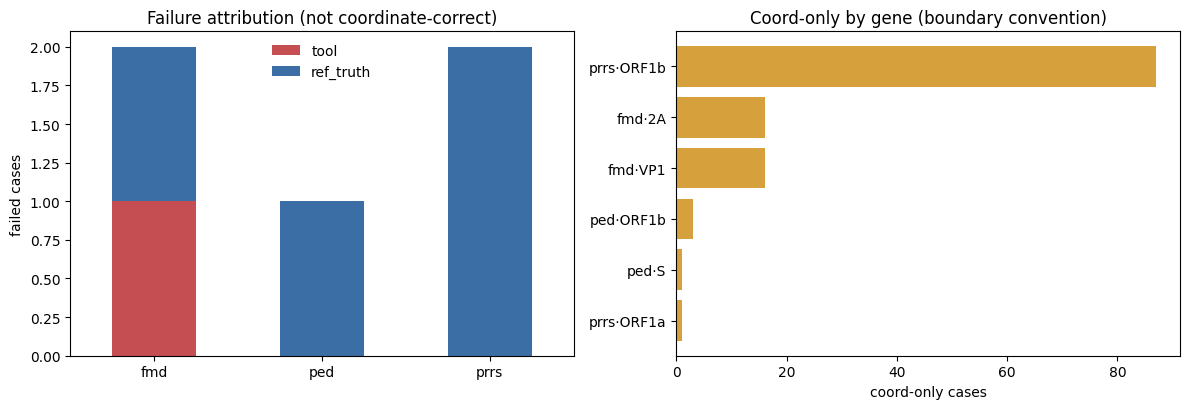

In [5]:
# coord_only = correct under the metric, but not base-identical
coord_only = per_pred[per_pred["coord_correct"].fillna(False) & ~per_pred["exact_match"].fillna(False)].copy()
co = (coord_only.groupby(["virus", "pred_name"])
        .agg(n=("iou", "size"), iou_min=("iou", "min"),
             dstart_mode=("delta_start", lambda s: s.mode().iloc[0] if len(s.mode()) else None),
             dend_mode=("delta_end", lambda s: s.mode().iloc[0] if len(s.mode()) else None))
        .reset_index().sort_values("n", ascending=False))
co.to_csv(OUT / "coord_only_breakdown.tsv", sep="\t", index=False)
print("coord-only (boundary convention, not error):")
print(co.head(15).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
pv = attr.pivot_table(index="virus", columns="blame", values="n", fill_value=0)
pv = pv.reindex(columns=[c for c in ["tool", "ref_truth", "review"] if c in pv.columns])
pv.plot.bar(stacked=True, ax=axes[0], rot=0,
            color=[{"tool": "#c44e52", "ref_truth": "#3b6ea5", "review": "#d6a13d"}[c] for c in pv.columns])
axes[0].set_ylabel("failed cases"); axes[0].set_xlabel("")
axes[0].set_title("Failure attribution (not coordinate-correct)"); axes[0].legend(frameon=False)

top = co.head(8)
axes[1].barh([f'{r.virus}·{r.pred_name}' for r in top.itertuples()][::-1], top["n"][::-1], color="#d6a13d")
axes[1].set_xlabel("coord-only cases"); axes[1].set_title("Coord-only by gene (boundary convention)")
fig.tight_layout(); fig.savefig(OUT / "failure_attribution.png", dpi=200, bbox_inches="tight")

## Interpretation

> Fill in after the run. The claim to make — and only if the table supports it — is that the
> residual failures are dominated by `blame = ref_truth` (the query's own annotation disagrees with
> the reference convention, or mislabels a gene) rather than `blame = tool`.
>
> State it with the adjudication rule in view, and note that the rule is generic and shipped. Do
> **not** phrase it as "our failures don't count" — a reviewer reads that as special pleading. The
> honest form is: *of N residual failures, M are attributable to the query annotation itself, and
> the specific records are listed.*